### ALGORITMO GENÉTICO



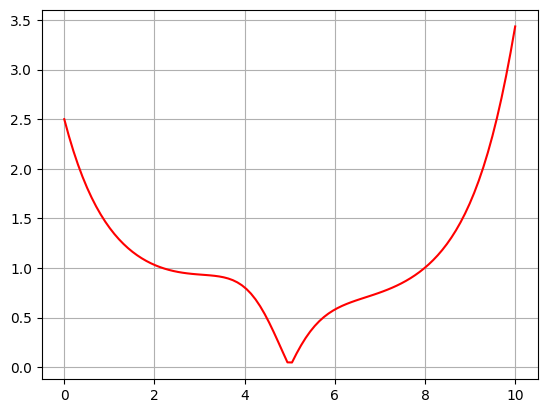

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
x = np.linspace(0,10,100)
y = abs((x-5)/(2+np.sin(x)))
plt.plot(x,y,'r')
plt.grid()
plt.show()

In [8]:
#Función que inicializa las amplitudes de probabilidad
#Al principio todas las amplitudes serán iguales 1/sqrt(2)

def amplitudes(tam_pob,num_qbits):
    pob_amp = np.full((tam_pob,num_qbits),1/np.sqrt(2))
    return pob_amp

A = amplitudes(10,5)
print(A)

[[0.70710678 0.70710678 0.70710678 0.70710678 0.70710678]
 [0.70710678 0.70710678 0.70710678 0.70710678 0.70710678]
 [0.70710678 0.70710678 0.70710678 0.70710678 0.70710678]
 [0.70710678 0.70710678 0.70710678 0.70710678 0.70710678]
 [0.70710678 0.70710678 0.70710678 0.70710678 0.70710678]
 [0.70710678 0.70710678 0.70710678 0.70710678 0.70710678]
 [0.70710678 0.70710678 0.70710678 0.70710678 0.70710678]
 [0.70710678 0.70710678 0.70710678 0.70710678 0.70710678]
 [0.70710678 0.70710678 0.70710678 0.70710678 0.70710678]
 [0.70710678 0.70710678 0.70710678 0.70710678 0.70710678]]


In [ ]:
#Función que genera soluciones binarias a partir de las amplitudes de probabilidad
def generar_soluciones(amplitudes):
    [renglones,columnas] = amplitudes.shape
    matriz_binaria = np.zeros((renglones,columnas),dtype=int)
    matriz_aleatoria = np.random.rand(renglones,columnas)
    for i in range(renglones):
        for j in range(columnas):
            if (matriz_aleatoria[i,j] < amplitudes[i,j]):
                matriz_binaria[i,j] = 1
            else:
                matriz_binaria[i,j] = 0
    return matriz_binaria

soluciones = generar_soluciones(A)
print(soluciones)    

[[1 1 0 1 1]
 [1 0 1 1 1]
 [1 0 1 1 1]
 [1 1 1 1 1]
 [1 1 0 1 1]
 [0 0 0 1 1]
 [0 0 1 1 1]
 [1 0 0 1 1]
 [1 0 1 1 1]
 [1 1 0 1 1]]


In [ ]:
#Función para evolucionar la población de individuos mediante rotation-gate
def rotation_gate(A,soluciones,mejor_solucion,theta=np.pi/50):
    [renglones,columnas] = A.shape
    for i in range(renglones):
        for j in range(columnas):
            if soluciones[i,j] != mejor_solucion[j]:
                if mejor_solucion[j] == 1:
                    A[i,j] = A[i,j] + np.sin(theta) * (1-A[i,j])
                else: 
                    A[i,j] = A[i,j] - np.sin(theta) * (1-A[i,j])
    A = np.clip(A,0.05,0.95)
    return A


In [14]:
# Funcion que implementa el operador de mutation-gate
def mutation_gate(A,pm = 0.05):
    [renglones,columnas] = A.shape
    M_aux = np.random.rand(renglones,columnas)
    mascara = np.zeros((renglones,columnas),dtype=bool)
    for i in range(renglones):
        for j in range(columnas):
            if M_aux[i,j] < pm:
                mascara[i,j] = True
            else:
                mascara[i,j] = False
    A = np.where(mascara, 1-A, A)
    return A

A = [[0.5,0.7,0.2],
    [0.3,0.4,0.8],
    [0.6,0.1,0.9]]
ejemplo = mutation_gate(np.array(A),0.5)
print(ejemplo)

[[0.5 0.7 0.2]
 [0.3 0.6 0.8]
 [0.6 0.9 0.9]]


In [1]:
import numpy as np

# ----------FUNCIONES----------

# Función Objetivo (acepta arrays)
def funcion_objetivo(x):
    return np.abs((x - 5) / (2 + np.sin(x)))

# Decodificar: acepta matriz (r, c) y devuelve vector de reales (r,)
def decodificar(poblacion, Imin, Imax):
    poblacion = np.asarray(poblacion)
    # Asegurar 2D
    if poblacion.ndim == 1:
        poblacion = poblacion.reshape(1, -1)
    r, c = poblacion.shape
    decimal = np.zeros(r)
    decimal_reescalado = np.zeros(r)
    for i in range(r):
        # convertir bits a entero
        valor = 0
        for j in range(c):
            valor += poblacion[i, j] * 2 ** (c - j - 1)
        decimal[i] = valor
        decimal_reescalado[i] = (Imax - Imin) * decimal[i] / (2 ** c - 1) + Imin
    return decimal_reescalado

# Función que inicializa las amplitudes de probabilidad
def amplitudes(tam_pob, num_qbits):
    return np.full((tam_pob, num_qbits), 1 / np.sqrt(2))

# Generar soluciones binarias según amplitudes (muestreo)
def generar_soluciones(amplitudes):
    renglones, columnas = amplitudes.shape
    matriz_binaria = np.zeros((renglones, columnas), dtype=int)
    matriz_aleatoria = np.random.rand(renglones, columnas)
    matriz_binaria = (matriz_aleatoria < amplitudes).astype(int)
    return matriz_binaria

# Rotation gate para acercar amplitudes a la mejor solución
def rotation_gate(A, soluciones, mejor_solucion, theta=np.pi/50):
    renglones, columnas = A.shape
    for i in range(renglones):
        for j in range(columnas):
            if soluciones[i, j] != mejor_solucion[j]:
                if mejor_solucion[j] == 1:
                    A[i, j] = A[i, j] + np.sin(theta) * (1 - A[i, j])
                else:
                    A[i, j] = A[i, j] - np.sin(theta) * (1 - A[i, j])
    A = np.clip(A, 0.05, 0.95)
    return A

# Mutation gate: con probabilidad pm invierte amplitudes (1 -> 0 y 0 -> 1)
def mutation_gate(A, pm=0.05):
    renglones, columnas = A.shape
    M_aux = np.random.rand(renglones, columnas)
    mascara = M_aux < pm
    A = np.where(mascara, 1 - A, A)
    return A

# ----------PARAMETROS----------
tam_pob = 20       # número de individuos
num_qbits = 8      # longitud de cromosomas
generaciones = 100 # generaciones
pm = 0.05          # probabilidad mutación
Imin = -10
Imax = 10

# --------EJECUCION------------
A = amplitudes(tam_pob, num_qbits)
mejor_fitness = float('inf')
mejor_solucion = None

for k in range(generaciones):
    soluciones = generar_soluciones(A)              # (tam_pob, num_qbits)
    xs = decodificar(soluciones, Imin, Imax)        # vector (tam_pob,)
    fitness = funcion_objetivo(xs)                  # vector (tam_pob,)
    idx = np.argmin(fitness)
    actual_mejor_fitness = float(fitness[idx])
    actual_mejor_solucion = soluciones[idx].copy()  # copia de la fila binaria

    # actualizar mejor global
    if actual_mejor_fitness < mejor_fitness:
        mejor_fitness = actual_mejor_fitness
        mejor_solucion = actual_mejor_solucion.copy()

    # evolucionar amplitudes respecto a la mejor solución de la generación global
    # usamos mejor_solucion global (si es None, usamos la mejor de la generación actual)
    referencia = mejor_solucion if mejor_solucion is not None else actual_mejor_solucion
    A = rotation_gate(A, soluciones, referencia)
    A = mutation_gate(A, pm)


# Resultado final
print("\nMejor fitness encontrado:", mejor_fitness)
print("Mejor solución (binaria):", mejor_solucion)
print("Mejor solución (real):", decodificar(mejor_solucion, Imin, Imax)[0])



Mejor fitness encontrado: 0.018932000813785942
Mejor solución (binaria): [1 0 1 1 1 1 1 1]
Mejor solución (real): 4.980392156862745
